<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# I.4 Tensão tangencial máxima. Círculo de Mohr.

## Problema 3 <a name="PI43"></a>

Considere o estado de tensão em redor do elemento infinitesimal centrado no ponto $P$ que é representado
na Figura.

[a)](#A) Escreva o tensor das tensões nesse ponto.

[b)](#B) Desenhe o diagrama de Mohr para esse estado de tensão.

[c)](#C) Explique o que são tensões principais e direcções principais de um estado de tensão.

[d)](#D) Determine analiticamente o tensor das tensões principais e a matriz de transformação que transforma o referencial dado no referencial principal e em seguida confirme os resultados obtidos pelo diagrama de Mohr.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au04/Au04_P003_i1.jpg"
width="300" height="220">

## Resolução

#### a) Escreva o tensor das tensões nesse ponto.<a name="A"></a>

([enunciatum](#PI43))

A matriz de tensão expressa no referencial $S(0,x,y,z)$ é dada por:

\begin{equation*}
\sigma_{ji} = [\sigma]^\top =
\begin{bmatrix}
60 & -80 & 0 \\
-80 & 0 & 0 \\
0 & 0 & -180
\end{bmatrix}~\textrm{MPa}
\end{equation*}

A tensão $\sigma_{zz} = -180$ MPa é uma tensão principal de tensão e a direção dos eixos dos $zz$ é uma direção
principal de tensão.

#### b) Desenhe o diagrama de Mohr para esse estado de tensão.<a name="B"></a>

([enunciatum](#PI43))

Método da circunferência de Mohr

Matriz das tensões tt0 = 
 [[  60  -80    0]
 [ -80    0    0]
 [   0    0 -180]]

PLANO x-y:
  Tensão normal mínima:  -55.44
  Tensão normal máxima:  115.44
  Tensão normal média :  30.0
Tensão de corte mínima:  -85.44
Tensão de corte máxima:  85.44
Ponto A ( 60.0 , 80.0 )
Ponto B ( 0.0 , -80.0 )

Tensão principal 1: 115.44  MPa
Tensão principal 2: -55.44  MPa
Tensão principal 3: -180.00  MPa


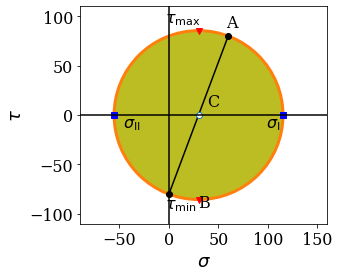

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 16
# rc('text', usetex=True)

def TensorTensoes(s11,s12,s13,s22,s23,s33):
    s21 = s12; s31 = s13; s32 = s23
    return np.array([[s11,s12,s13], [s21,s22,s23], [s31,s32,s33]])

tt0 = TensorTensoes(60,-80,0,0,0,-180)
print('Matriz das tensões tt0 = \n',tt0)

def mohr(S,limits):
    """Plot Mohr circle for a 2D tensor"""
    S11 = S[0][0]
    S12 = S[0][1]
    S22 = S[1][1]
    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)
    Smin = center[0] - radius
    Smax = center[0] + radius

    print("  Tensão normal mínima: ", np.round(Smin,3))
    print("  Tensão normal máxima: ", np.round(Smax,3))
    print("  Tensão normal média : ", np.round(center[0],3))
    print("Tensão de corte mínima: ", np.round(-radius,3))
    print("Tensão de corte máxima: ", np.round(radius,3))

    print('Ponto A (','{:.1f}'.format(S11),',','{:.1f}'.format(-S12),')')
    print('Ponto B (','{:.1f}'.format(S22),',','{:.1f}'.format(S12),')')

    circ = plt.Circle((center[0],0), radius, facecolor='tab:olive', lw=3,
    edgecolor='tab:orange')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Smin - .3*radius, Smax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([S11, S22], [-S12, S12], 'ko')
    plt.plot([S11, S22], [-S12, S12], 'k')
    plt.plot(Smin, 0, 'bs')
    plt.plot(Smax, 0, 'bs')
    plt.plot(center[0], radius, 'rv')
    plt.plot(center[0], -radius, 'rv')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    plt.text(S11 - .2*desv, -S12 + desv , 'A')
    plt.text(S22 + 3.5*desv, S12 - 1.5*desv, 'B')
    plt.text(Smin + .1*radius, -0.15*radius, r'$\sigma_\mathrm{II}$')
    plt.text(Smax - .2*radius, -0.15*radius, r'$\sigma_\mathrm{I}$')
    plt.text(center[0]-4*desv, 1.1*radius, r'$\tau_\mathrm{max}$')
    plt.text(center[0]-4*desv, -1.1*radius, r'$\tau_\mathrm{min}$')
    plt.xlabel(r"$\sigma$", size=18)
    plt.ylabel(r"$\tau$", size=18)
    plt.xlim(limits[0,0],limits[0,1])
    plt.ylim(limits[1,0],limits[1,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

axislim = np.array([[-90,160],[-110,110]])
print('\n================================')
print('PLANO x-y:')
print('================================')
sxx = tt0[0,0]
syy = tt0[1,1]
sxy = tt0[0,1]
S = np.array([[sxx, sxy],[sxy, syy]])
mohr(S, axislim)

center = (sxx + syy)/2
radius = np.sqrt((sxx - syy)**2/4.0 + sxy**2)
smax = center + radius
smin = center - radius
print('\nTensão principal 1:','{:.2f}'.format(smax),' MPa')
print('Tensão principal 2:','{:.2f}'.format(smin),' MPa')
print('Tensão principal 3:','{:.2f}'.format(tt0[2,2]),' MPa')

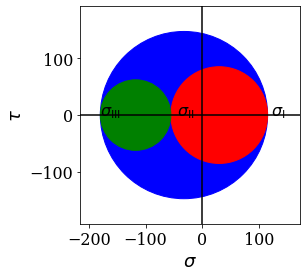

In [2]:
def circleradius(S):
    S11 = S[0,0]
    S12 = S[0,1]
    S22 = S[1,1]

    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)

    return center, radius

limits = np.array([[-200,200],[-100,100]])

sigI = smax
sigII = smin
sigIII = tt0[2,2]

s11 = sigI; s22 = sigIII; s12 = 0
S = np.array([[s11, s12],[s12, s22]])
center1, radius1  = circleradius(S)

s11 = sigI; s22 = sigII; s12 = 0
S = np.array([[s11, s12],[s12, s22]])
center2, radius2  = circleradius(S)

s11 = sigII; s22 = sigIII; s12 = 0
S = np.array([[s11, s12],[s12, s22]])
center3, radius3  = circleradius(S)

circ1 = plt.Circle((center1[0],0), radius1, facecolor='b', lw=1,edgecolor='b')
circ2 = plt.Circle((center2[0],0), radius2, facecolor='r', lw=1,edgecolor='r')
circ3 = plt.Circle((center3[0],0), radius3, facecolor='g', lw=1,edgecolor='g')

plt.axis('image'); ax = plt.gca()

plt.gcf().gca().add_artist(circ1)
plt.gcf().gca().add_artist(circ2)
plt.gcf().gca().add_artist(circ3)

ax.set_xlim(1.2*sigIII, 1.5*sigI)
ax.set_ylim(-1.3*radius1, 1.3*radius1)

plt.xlabel(r"$\sigma$", size=18)
plt.ylabel(r"$\tau$", size=18)

plt.text(1.05*sigI, 0, r'$\sigma_\mathrm{I}$')
plt.text(.8*sigII, 0, r'$\sigma_\mathrm{II}$')
plt.text(1.*sigIII, 0, r'$\sigma_\mathrm{III}$')

#plt.xlim(limits[0,0],limits[0,1])
#plt.ylim(limits[1,0],limits[1,1])

ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')

plt.show()

Análise das equações de transformação

--------------------------
Equações de transformação:
--------------------------

Matriz das tensões tt0 = 
 [[  60  -80    0]
 [ -80    0    0]
 [   0    0 -180]]

PLANO x-y:

Tensões (normais) principais: -------------------------------------------
angPrincipal 1 (deg) = -34.72
tens xx plano principal [1] (MPa) = 115.44
tens yy plano principal [1] (MPa) = -55.44
tens xy plano principal [1] (MPa) = 0.00

angPrincipal 2 (deg) = 55.28
tens xx plano principal [2] (MPa) = -55.44
tens yy plano principal [2] (MPa) = 115.44
tens xy plano principal [2] (MPa) = -0.00

Tensões de corte maximas/mínima: -------------------------------------------
Ângulo tensão corte max (Deg) = 10.28
tens xx - plano  tensão de corte max (MPa) = 30.00
tens yy - plano  tensão de corte max (MPa) = 30.00
tens xy - plano  tensão de corte max (MPa) = -85.44
Ângulo tensão corte min (Deg) = 100.28
tens xx - plano  tensão de corte min (MPa) = 30.00
tens yy - plano  tensão de corte min (MPa) = 30.00
tens xy - plano  tensão

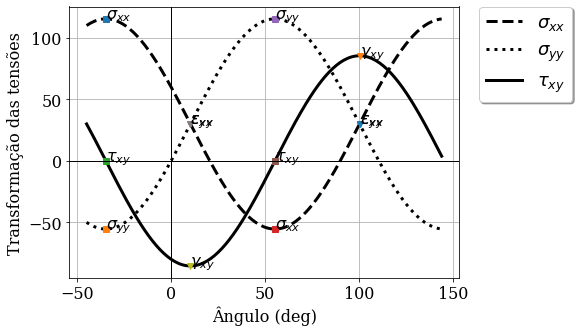

In [3]:
print('--------------------------')
print('Equações de transformação:')
print('--------------------------')

print('\nMatriz das tensões tt0 = \n',tt0)

def sxx1(sxx,syy,txy,t):
    return (sxx+syy)/2 + (sxx-syy)/2*np.cos(2*t) + txy*np.sin(2*t)

def syy1(sxx,syy,txy,t):
    return (sxx+syy)/2 - (sxx-syy)/2*np.cos(2*t) - txy*np.sin(2*t)

def txy1(sxx,syy,txy,t):
    return (syy-sxx)/2*np.sin(2*t) + txy*np.cos(2*t)

def angPrincipal(sxx,syy,txy):
    return np.arctan(2*txy/(sxx-syy))/2

def angS(s11,s22,s12): return -np.arctan((s11-s22)/(2*s12))

print('\nPLANO x-y:\n')
sxx = tt0[0,0] # neste caso: x = y; y = z
txy = tt0[0,1]
syy = tt0[1,1]

angt = np.arange(-45,145,1)
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

print('Tensões (normais) principais: -------------------------------------------')
aprinc = np.rad2deg(angPrincipal(sxx,syy,txy))
print('angPrincipal 1 (deg) =','{:.2f}'.format(aprinc))
tsxx1 = sxx1(sxx,syy,txy,np.deg2rad(aprinc))
tsyy1 = syy1(sxx,syy,txy,np.deg2rad(aprinc))
ttxy1 = txy1(sxx,syy,txy,np.deg2rad(aprinc))
print('tens xx plano principal [1] (MPa) =','{:.2f}'.format(tsxx1))
print('tens yy plano principal [1] (MPa) =','{:.2f}'.format(tsyy1))
print('tens xy plano principal [1] (MPa) =','{:.2f}'.format(ttxy1))

aprinc2 = aprinc + 90
print('\nangPrincipal 2 (deg) =','{:.2f}'.format(aprinc2))
tsxx2 = sxx1(sxx,syy,txy,np.deg2rad(aprinc2))
tsyy2 = syy1(sxx,syy,txy,np.deg2rad(aprinc2))
ttxy2 = txy1(sxx,syy,txy,np.deg2rad(aprinc2))
print('tens xx plano principal [2] (MPa) =','{:.2f}'.format(tsxx2))
print('tens yy plano principal [2] (MPa) =','{:.2f}'.format(tsyy2))
print('tens xy plano principal [2] (MPa) =','{:.2f}'.format(ttxy2))

print('\nTensões de corte maximas/mínima: -------------------------------------------')
aS1 = angS(sxx,syy,txy)/2 # ângulo no espaço físico, radianos
print('Ângulo tensão corte max (Deg) =','{:.2f}'.format(np.rad2deg(aS1)))
tcortexxMa = sxx1(sxx,syy,txy,aS1)
tcorteyyMa = syy1(sxx,syy,txy,aS1)
tcortexyMa = txy1(sxx,syy,txy,aS1)
print('tens xx - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcortexxMa))
print('tens yy - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcorteyyMa))
print('tens xy - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcortexyMa))

aS2 = aS1 + np.pi/2
print('Ângulo tensão corte min (Deg) =','{:.2f}'.format(np.rad2deg(aS2)))
tcortexxMb = sxx1(sxx,syy,txy,aS2)
tcorteyyMb = syy1(sxx,syy,txy,aS2)
tcortexyMb = txy1(sxx,syy,txy,aS2)
print('tens xx - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexxMb))
print('tens yy - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcorteyyMb))
print('tens xy - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexyMb))

# use LaTeX fonts in the plot
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(angt, tsxx, 'k--', label=r'$\sigma_{xx}$', linewidth=3)
ax.plot(angt, tsyy, 'k:', label=r'$\sigma_{yy}$', linewidth=3)
ax.plot(angt, ttxy, 'k', label=r'$\tau_{xy}$', linewidth=3)
# points: principal stresses
ax.plot(aprinc, tsxx1, 's'), ax.text(aprinc, tsxx1,r'$\sigma_{xx}$')
ax.plot(aprinc, tsyy1, 's'), ax.text(aprinc, tsyy1,r'$\sigma_{yy}$')
ax.plot(aprinc, ttxy1, 's'), ax.text(aprinc, ttxy1,r'$\tau_{xy}$')
ax.plot(aprinc2, tsxx2, 's'), ax.text(aprinc2, tsxx2,r'$\sigma_{xx}$')
ax.plot(aprinc2, tsyy2, 's'), ax.text(aprinc2, tsyy2,r'$\sigma_{yy}$')
ax.plot(aprinc2, ttxy2, 's'), ax.text(aprinc2, ttxy2,r'$\tau_{xy}$')
# points: critical shear stresses
ax.plot(np.rad2deg(aS1), tcortexxMa, 'v')
ax.text(np.rad2deg(aS1), tcortexxMa,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aS1), tcorteyyMa, 'v')
ax.text(np.rad2deg(aS1), tcorteyyMa,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aS1), tcortexyMa, 'v')
ax.text(np.rad2deg(aS1), tcortexyMa,r'$\gamma_{xy}$')
ax.plot(np.rad2deg(aS2), tcortexxMb, 'v')
ax.text(np.rad2deg(aS2), tcortexxMb,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aS2), tcorteyyMb, 'v')
ax.text(np.rad2deg(aS2), tcorteyyMb,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aS2), tcortexyMb, 'v')
ax.text(np.rad2deg(aS2), tcortexyMb,r'$\gamma_{xy}$')

ax.set(xlabel='Ângulo (deg)', ylabel='Transformação das tensões')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

#### c) Explique o que são tensões principais e direcções principais de um estado de tensão.<a name="C"></a>

([enunciatum](#PI43))

Num determinado ponto matarial de um objeto é possível definir um elemento infinitesimal com três facetas mutuamente
ortogonais entre si e para as quais os vetores tensão têm a direção das suas normais.
Neste caso os vetores tensão têm apenas componente normal sendo, portanto, nulas todas as componentes de tensão de
corte. As normais a esses facetas definem um sistema de coordenadas ortonormado e direto, cujos eixos são direções
principais. As tensões normais nele definidas são ditas de tensões
principais e representam nesse ponto as tensões normais máximas ou mínimas.

Por analogia à Álgebra Linear, as matrizes simétricas, como é exemplo a matriz das tensões em relação a um determinado
referencial, são diagonalizáveis sendo os valores da diagonal designados por valores própriose e as direções a que estão
associados por vetores próprios.

#### d) Determine analiticamente o tensor das tensões principais e a matriz de transformação que transforma o referencial dado no referencial principal e em seguida confirme os resultados obtidos pelo diagrama de Mohr.<a name="D"></a>

([enunciatum](#PI43))

As tensões principais obtêm-se de:

\begin{equation*}
\det(\sigma_{ij} - \sigma\delta_{ij})= 0
\end{equation*}

\begin{equation*}
\sigma^3 - I_1\sigma^2 + I_2\sigma - I_3 = 0
\end{equation*}

\begin{equation*}
\begin{aligned}
I_1 &= \mathrm{Tr}(\sigma_{ij}) \\
I_2 &= \frac{1}{2}\left[ \mathrm{Tr}(\sigma_{ij})^2 - \mathrm{Tr}(\sigma_{ij}^2) \right] =
\frac{1}{2}\left( \sigma_{ii}\sigma_{jj} - \sigma_{ij}\sigma_{ji} \right) \\
& =
\begin{vmatrix}
\sigma_{11} & \sigma_{12} \\
\sigma_{21} & \sigma_{22} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{11} & \sigma_{13} \\
\sigma_{31} & \sigma_{33} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{22} & \sigma_{23} \\
\sigma_{32} & \sigma_{33} \\
\end{vmatrix} \\\\
I_3 &= \mathrm{det}(\sigma_{ij}) \\
\end{aligned}
\end{equation*}

In [4]:
from sympy.solvers import solve
from sympy import symbols

print('\n Calculo dos invariantes pela matriz das tensões  : ............................')

I1 = np.trace(tt0)
print('1º Invariante, I1:', '{:.1f}'.format(I1))

I2 = 0.5*(np.trace(tt0)**2 -np.trace(np.dot(tt0,tt0)))
print('2º Invariante, I2 :', '{:.1f}'.format(I2))

I3 = np.linalg.det(tt0)
print('3º Invariante, I3 :', '{:.1f}'.format(I3))

print('\n Resolucao Simbolica - Sympy : ............................')
x = symbols('x')
def eqcar(x): return x**3 - I1*x**2 + I2*x - I3
print('\n Equacao carateristica:')
print(eqcar(x),' = 0')
valproprios = solve(eqcar(x), x, dict=True)
print('\n sol : ')
print(valproprios)
sI = valproprios[2][x]
sII = valproprios[1][x]
sIII = valproprios[0][x]
print('\n1º valor próprio, sI = ','{:.1f}'.format(sI))
print('2º valor próprio, sII = ','{:.1f}'.format(sII))
print('3º valor próprio, sIII = ','{:.1f}'.format(sIII))

print('\n Calculo invariantes Ii (sI,SII,sIII) : \n')
I1vp = sI + sII + sIII
print('I1 (sI,SII,sIII) = ','{:.1f}'.format(I1vp))
I2vp = sI*sII + sII*sIII + sI*sIII
print('I2 (sI,SII,sIII) = ','{:.1f}'.format(I2vp))
I3vp = sI*sII*sIII
print('I3 (sI,SII,sIII) = ','{:.1f}'.format(I3vp))

print('\n Resolucao Numerica - Numpy : ............................')
valpropriosN = np.roots([1,-I1,I2,-I3])
print('\n Roots = ',-np.sort(-valpropriosN))

print('\n Resolucao Analítica - Formula recursiva Poly3: ..........')
print('\n p(x) = x**3 + a x**2 + b*c + c = 0')
def frPoly3(a,b,c):
    p = b-a**2/3
    q = (2*a**3)/27 - (a*b)/3 + c
    DeltaPoly3 = q**2/4 + p**3/27
    print('\nDelta(Poly3) :', DeltaPoly3)
    if DeltaPoly3 < 0:
        print('existe três soluções reais')
        x1 = (2/np.sqrt(3))*np.sqrt(-p)*np.sin((1/3)*np.arcsin((3*np.sqrt(3)*q)/(2*np.sqrt(-p)**3))) - a/3
        x2 = -(2/np.sqrt(3))*np.sqrt(-p)*np.sin((1/3)*np.arcsin((3*np.sqrt(3)*q)/(2*np.sqrt(-p)**3)) + np.pi/3) - a/3
        x3 = (2/np.sqrt(3))*np.sqrt(-p)*np.cos((1/3)*np.arcsin((3*np.sqrt(3)*q)/(2*np.sqrt(-p)**3)) + np.pi/6) - a/3
    elif DeltaPoly3 == 0:
        print('existe três raízes repetidas')
        x1 = -2*(q/2)**(1/3) - a/3
        x2 = (q/2)**(1/3) - a/3
        x3 = x2
    else:
        print('existe apenas uma única solução real')
        x1 = (-q/2 + np.sqrt(DeltaPoly3))**(1/3) + (-q/2 - np.sqrt(DeltaPoly3))**(1/3) - a/3
        x2 = x1; x3 = x1

    return  np.array([x1,x2,x3])

valpropfrPoly3 = frPoly3(-I1,I2,-I3)
print('\n Formula recursiva Poly3 = ',-np.sort(-valpropfrPoly3))


 Calculo dos invariantes pela matriz das tensões  : ............................
1º Invariante, I1: -120.0
2º Invariante, I2 : -17200.0
3º Invariante, I3 : 1152000.0

 Resolucao Simbolica - Sympy : ............................

 Equacao carateristica:
x**3 + 120*x**2 - 17200.0*x - 1152000.0  = 0

 sol : 
[{x: -180.000000000000}, {x: -55.4400374531753}, {x: 115.440037453175}]

1º valor próprio, sI =  115.4
2º valor próprio, sII =  -55.4
3º valor próprio, sIII =  -180.0

 Calculo invariantes Ii (sI,SII,sIII) : 

I1 (sI,SII,sIII) =  -120.0
I2 (sI,SII,sIII) =  -17200.0
I3 (sI,SII,sIII) =  1152000.0

 Resolucao Numerica - Numpy : ............................

 Roots =  [ 115.44003745  -55.44003745 -180.        ]

 Resolucao Analítica - Formula recursiva Poly3: ..........

 p(x) = x**3 + a x**2 + b*c + c = 0

Delta(Poly3) : -366146370370.37054
existe três soluções reais

 Formula recursiva Poly3 =  [ 115.44003745  -55.44003745 -180.        ]


**Polinómio caraterístico**

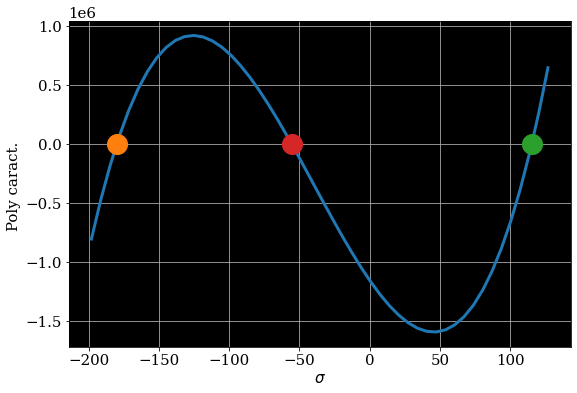

In [5]:
srange = np.linspace(np.min(valpropfrPoly3)*1.1,np.max(valpropfrPoly3)*1.1)
def polycaract(s):
    return s**3 - I1*s**2 + I2*s - I3

AAA = polycaract(srange)
import matplotlib.pyplot as plt
font = {'size'   : 15}
plt.rc('font', **font)
plt.rcParams['axes.facecolor']='black'
plt.figure(figsize=(9,6))
plt.plot(srange,polycaract(srange),linewidth=3)
for i in valpropriosN:
    plt.plot(i,polycaract(i),'o',markersize=20)
plt.ylabel('Poly caract. ')
plt.xlabel('$\sigma$')
plt.grid('on')
plt.show()

As direções principais associadas as tensões principais são determinadas pela solução do seguinte sistema de equações:

\begin{equation*}
(\sigma_{ij} - \sigma_\alpha\delta_{ij})\cdot n_j = 0 \quad \wedge \quad n_i \cdot n_i = 1
\quad (\alpha = \mathrm{I,II,III})
\end{equation*}

In [6]:
from sympy.solvers import solve
from sympy import symbols

d1,d2,d3 = symbols('d1 d2 d3')

def eq1(d1,d2,d3,vp): return (tt0[0,0] - vp)*d1 + tt0[0,1]*d2 + tt0[0,2]*d3
def eq2(d1,d2,d3,vp): return tt0[1,0]*d1 + (tt0[1,1] - vp)*d2 + tt0[1,2]*d3
def eq3(d1,d2,d3,vp): return tt0[2,0]*d1 + tt0[2,1]*d2 + (tt0[2,2] - vp)*d3
def eq4(d1,d2,d3): return d1**2 + d2**2 + d3**2 - 1

def versor(e1,e2,e3): return np.array([e1,e2,e3])

# 1 valor proprio -------------------
print('\nVetor próprio associado a sI = ','{:.2f}'.format(sI),'.............................')
print('\n(i) sistema de equações:')
E1_sI = eq1(d1,d2,d3,sI); print(E1_sI,' = 0')
E2_sI = eq2(d1,d2,d3,sI); print(E2_sI,' = 0')
E3_sI = eq3(d1,d2,d3,sI); print(E3_sI,' = 0')
E4_sI = eq4(d1,d2,d3); print(E4_sI,' = 0')
VetProp1 = solve([E1_sI,E3_sI,E4_sI], [d1,d2,d3], dict=True)
l1 = float(VetProp1[1][d1])
m1 = float(VetProp1[1][d2])
n1 = float(VetProp1[1][d3])
versorI = versor(l1,m1,n1)
print('\n (ii) nI = (','{:.3f}'.format(l1),') e1 + (','{:.3f}'.format(m1),') e2 + (','{:.3f}'.format(n1),') e3')


Vetor próprio associado a sI =  115.44 .............................

(i) sistema de equações:
-55.4400374531753*d1 - 80*d2  = 0
-80*d1 - 115.440037453175*d2  = 0
-295.440037453175*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

 (ii) nI = ( 0.822 ) e1 + ( -0.570 ) e2 + ( 0.000 ) e3


\begin{equation*}
\vec{n}_\mathrm{I} \equiv \vec{\imath}_\mathrm{P} = 0.822~\vec{\imath} -0.570~\vec{\jmath}
\end{equation*}

In [7]:
# 2 valor proprio -------------------
print('\nVetor próprio associado a sII= ','{:.2f}'.format(sII),' .............................')
print('\n (i) sistema de equações:')
E1_sII = eq1(d1,d2,d3,sII); print(E1_sII,' = 0')
E2_sII = eq2(d1,d2,d3,sII); print(E2_sII,' = 0')
E3_sII = eq3(d1,d2,d3,sII); print(E3_sII,' = 0')
E4_sII = eq4(d1,d2,d3); print(E4_sII,' = 0')
VetProp2 = solve([E1_sII,E3_sII,E4_sII], [d1,d2,d3], dict=True)
l2 = float(VetProp2[1][d1])
m2 = float(VetProp2[1][d2])
n2 = float(VetProp2[1][d3])
versorII = versor(l2,m2,n2)
print('\n (ii) nII = (','{:.3f}'.format(l2),') e1 + (','{:.3f}'.format(m2),') e2 + (','{:.3f}'.format(n2),') e3')


Vetor próprio associado a sII=  -55.44  .............................

 (i) sistema de equações:
115.440037453175*d1 - 80*d2  = 0
-80*d1 + 55.4400374531753*d2  = 0
-124.559962546825*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

 (ii) nII = ( 0.570 ) e1 + ( 0.822 ) e2 + ( 0.000 ) e3


\begin{equation*}
\vec{n}_\mathrm{II} \equiv \vec{\jmath}_\mathrm{P} = 0.570~\vec{\imath} + 0.822~\vec{\jmath}
\end{equation*}

In [8]:
# 3 valor proprio -------------------
print('\nVetor próprio associado a sIII= ','{:.2f}'.format(sIII),' .............................')
print('\n (i) sistema de equações:')
E1_sIII = eq1(d1,d2,d3,sIII); print(E1_sIII,' = 0')
E2_sIII = eq2(d1,d2,d3,sIII); print(E2_sIII,' = 0')
E3_sIII = eq3(d1,d2,d3,sIII); print(E3_sIII,' = 0')
E4_sIII = eq4(d1,d2,d3); print(E4_sIII,' = 0')
VetProp3 = solve([E1_sIII,E2_sIII,E4_sIII], [d1,d2,d3], dict=True)
l3 = float(VetProp3[1][d1])
m3 = float(VetProp3[1][d2])
n3 = float(VetProp3[1][d3])
versorIII = versor(l3,m3,n3)
print('\n (ii) nIII = (','{:.3f}'.format(l3),') e1 + (','{:.3f}'.format(m3),') e2 + (','{:.3f}'.format(n3),') e3')


Vetor próprio associado a sIII=  -180.00  .............................

 (i) sistema de equações:
240.0*d1 - 80*d2  = 0
-80*d1 + 180.0*d2  = 0
0  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

 (ii) nIII = ( 0.000 ) e1 + ( 0.000 ) e2 + ( 1.000 ) e3


\begin{equation*}
\vec{n}_\mathrm{III} \equiv \vec{k}_\mathrm{P} = \vec{k} \quad\textrm{(rotação em torno do eixo comum dos $zz$)}
\end{equation*}

In [9]:
print('\n Verificação - sistema de coordenadas ortonormado e direto: ')
print('dot(vp1,vp1) = ','{:.1f}'.format(np.dot(versorI,versorI)))
print('dot(vp2,vp2) = ', '{:.1f}'.format(np.dot(versorII,versorII)))
print('dot(vp3,vp3) = ', '{:.1f}'.format(np.dot(versorIII,versorIII)))
print('dot(vp1,vp2) = ', '{:.0f}'.format(np.dot(versorI,versorII)))
print('dot(vp2,vp3) = ', np.dot(versorII,versorIII))
print('dot(vp1,vp3) = ', '{:.0f}'.format(np.abs(np.dot(versorI,versorIII))))


 Verificação - sistema de coordenadas ortonormado e direto: 
dot(vp1,vp1) =  1.0
dot(vp2,vp2) =  1.0
dot(vp3,vp3) =  1.0
dot(vp1,vp2) =  0
dot(vp2,vp3) =  0.0
dot(vp1,vp3) =  0


In [10]:
np.set_printoptions(precision=3)
print('\n Matriz de transformação de S0 para SI (ref. principal): ')

print('\n Àngulo entre eI e x: ')
print('\n theta_P = ','{:.2f}'.format(np.rad2deg(np.arccos(l1))), ' Deg')

mT = np.concatenate((versorI, versorII,versorIII))
mT = mT.reshape(3,3)
print('\n [T] = \n', mT)

print('\n[T][T]^T = I :\n',np.dot(np.transpose(mT),mT))

print('\n det(T) = ','{:.2f}'.format(np.linalg.det(mT)))

print('\nverificacao: ni.ni = 1 ')
eI2 = np.sqrt(np.dot(mT[0,:],mT[0,:]))
print('T[0,:] : eI2 = ','{:.2f}'.format(eI2))
eII2 = np.sqrt(np.dot(mT[1,:],mT[1,:]))
print('T[1,:] : eII2 = ','{:.2f}'.format(eII2))
eIII2 = np.sqrt(np.dot(mT[2,:],mT[2,:]))
print('T[2,:] : eII2 = ','{:.2f}'.format(eIII2))


 Matriz de transformação de S0 para SI (ref. principal): 

 Àngulo entre eI e x: 

 theta_P =  34.72  Deg

 [T] = 
 [[ 0.822 -0.57   0.   ]
 [ 0.57   0.822  0.   ]
 [ 0.     0.     1.   ]]

[T][T]^T = I :
 [[1.000e+00 4.441e-16 0.000e+00]
 [4.441e-16 1.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 1.000e+00]]

 det(T) =  1.00

verificacao: ni.ni = 1 
T[0,:] : eI2 =  1.00
T[1,:] : eII2 =  1.00
T[2,:] : eII2 =  1.00


In [11]:
def angP(s11,s22,s12): return np.arctan((2*s12)/(s11-s22))

sxx = tt0[0,0]
syy = tt0[1,1]
sxy = tt0[0,1]

aP1 = angP(sxx,syy,sxy)
aP2 = aP1 + np.pi

print('angulos das direções principais')
print('\nNo espaço das tensões:')
print('angPI  = ','{:.3f}'.format(np.rad2deg(aP1)),' deg | ','{:.3f}'.format(aP1),' radians')
print('angPII = ','{:.3f}'.format(np.rad2deg(aP2)),' deg | ','{:.3f}'.format(aP2),' radians')

aPI = aP1/2
aPII = aP2/2

print('\nNo espaço fisico:')
print('angPI  =  ','{:.3f}'.format(np.rad2deg(aPI)),' deg | ','{:.3f}'.format(aPI),' radians')
print('angPII = ','{:.3f}'.format(np.rad2deg(aPII)),' deg | ','{:.3f}'.format(aPII),' radians')

def Q(ang,rot):
    c = np.cos(ang)
    s = np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

MatrTrans = Q(aPI,3)
print('\nMatriz de transformação = \n',MatrTrans)

print('\nVetores principais:')
nI = MatrTrans[0,:]
print('eI = ', nI)
nII = MatrTrans[1,:]
print('eII = ', nII)
nIII = MatrTrans[2,:]
print('eIII = ', nIII)

angulos das direções principais

No espaço das tensões:
angPI  =  -69.444  deg |  -1.212  radians
angPII =  110.556  deg |  1.930  radians

No espaço fisico:
angPI  =   -34.722  deg |  -0.606  radians
angPII =  55.278  deg |  0.965  radians

Matriz de transformação = 
 [[ 0.822 -0.57   0.   ]
 [ 0.57   0.822  0.   ]
 [ 0.     0.     1.   ]]

Vetores principais:
eI =  [ 0.822 -0.57   0.   ]
eII =  [0.57  0.822 0.   ]
eIII =  [0. 0. 1.]


Matriz de transformação:

\begin{equation*}
[A] =
\begin{bmatrix}
\cos\theta & \sin\theta & 0 \\
-\sin\theta & \cos\theta & 0 \\
0 & 0 & 1 \\
\end{bmatrix} =
\begin{bmatrix}
0.8219 & -0.5696 & 0 \\
0.5696 & 0.8219 & 0 \\
0 & 0 & 1 \\
\end{bmatrix}
\end{equation*}

Matriz de tensão no referencial principal:

\begin{equation*}
[\sigma] =
\begin{bmatrix}
\sigma_\mathrm{I} & 0 & 0 \\
0 & \sigma_\mathrm{II} & 0 \\
0 & 0 & \sigma_\mathrm{III} \\
\end{bmatrix} =
\begin{bmatrix}
115.44 & 0 & 0 \\
0 & -55.44 & 0 \\
0 & 0 & -180.00 \\
\end{bmatrix} \textrm{MPa}
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au04/Au04_P003_i2.jpg"
width="400" height="375">

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>